In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
df=pd.read_csv("/Users/pruth/Downloads/diamonds.csv")

In [4]:
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [8]:
y=df["price"]
x=df[['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y',
       'z']]

In [13]:
from sklearn.model_selection import train_test_split


In [14]:
xt,xtt,yt,ytt=train_test_split(x,y,train_size=0.80,random_state=1)

In [15]:
from sklearn.preprocessing import StandardScaler,OneHotEncoder
s=StandardScaler()
o=OneHotEncoder(sparse_output=False,drop=None)

In [16]:
xt_n=xt.select_dtypes(include="number")
xtt_n=xtt.select_dtypes(include="number")
xt_o=xt.select_dtypes(include="object")
xtt_o=xtt.select_dtypes(include="object")

In [17]:
xt_n_t=pd.DataFrame(s.fit_transform(xt_n),columns=xt_n.columns)
xtt_n_t=pd.DataFrame(s.transform(xtt_n),columns=xtt_n.columns)

In [23]:
xt_n_t

,carat,depth,table,x,y,z
0,-0.813799,0.386083,-1.991090,-0.824818,-0.834724,-0.784375
1,0.678822,-0.870973,0.689861,0.944278,0.866469,0.779256
2,-0.792777,-0.801137,-0.650615,-0.798148,-0.747928,-0.840722
3,0.510639,0.525756,0.689861,0.650910,0.588723,0.680649
4,-0.204137,-2.337539,1.136686,0.099735,0.120027,-0.164557
...,...,...,...,...,...,...
43147,-0.204137,0.735265,0.689861,-0.149183,-0.105641,-0.037776
43148,-0.834822,1.503467,-0.203789,-0.904827,-0.938878,-0.770288
43149,0.237342,0.665429,2.477162,0.286423,0.232861,0.342567
43150,0.804959,-0.032936,-0.650615,0.944278,0.944585,0.934211


In [345]:
xt_o.columns = xt_o.columns.astype(str)
xt_o.columns = xtt_o.columns.astype(str)


In [25]:
xt_o_t=pd.DataFrame(o.fit_transform(xt_o),columns=o.get_feature_names_out(xt_o.columns))
xtt_o_t=pd.DataFrame(o.transform(xtt_o),columns=o.get_feature_names_out(xtt_o.columns))

In [28]:
xt_no=pd.concat([xt_o_t,xt_n_t],axis=1)
xtt_no=pd.concat([xtt_o_t,xtt_n_t],axis=1)
xtt_no.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10788 entries, 0 to 10787
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cut_Fair       10788 non-null  float64
 1   cut_Good       10788 non-null  float64
 2   cut_Ideal      10788 non-null  float64
 3   cut_Premium    10788 non-null  float64
 4   cut_Very Good  10788 non-null  float64
 5   color_D        10788 non-null  float64
 6   color_E        10788 non-null  float64
 7   color_F        10788 non-null  float64
 8   color_G        10788 non-null  float64
 9   color_H        10788 non-null  float64
 10  color_I        10788 non-null  float64
 11  color_J        10788 non-null  float64
 12  clarity_I1     10788 non-null  float64
 13  clarity_IF     10788 non-null  float64
 14  clarity_SI1    10788 non-null  float64
 15  clarity_SI2    10788 non-null  float64
 16  clarity_VS1    10788 non-null  float64
 17  clarity_VS2    10788 non-null  float64
 18  clarit

In [362]:
from sklearn.linear_model import LinearRegression

In [363]:
regression=LinearRegression()

In [364]:
regression.fit(xt_no,yt)

LinearRegression()

In [365]:
predict=regression.predict(xtt_no)

In [52]:
from sklearn import metrics

In [367]:
metrics.mean_absolute_error(ytt,predict)

733.1476075848165

### lable encoding

In [370]:
from sklearn.preprocessing import LabelEncoder

In [371]:
le=LabelEncoder()
xt_o_le=pd.DataFrame(le.fit_transform(xt_o.cut))

In [372]:
xt_o_le

,0
0,2
1,3
2,2
3,3
4,1
...,...
43147,4
43148,1
43149,4
43150,2


## Ordinal Encoder

In [30]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder(categories=[[]])
xt_o_oe=pd.DataFrame(oe.fit_transform())

TypeError: TransformerMixin.fit_transform() missing 1 required positional argument: 'X'

In [32]:
oe

OrdinalEncoder(categories=[[]])

In [34]:
xt_o

,cut,color,clarity
42836,Ideal,F,VVS1
9727,Premium,F,SI2
35974,Ideal,F,VS1
22501,Premium,E,VVS1
3571,Good,E,VS1
...,...,...,...
50057,Very Good,I,VS2
32511,Good,E,SI2
5192,Very Good,G,VS2
12172,Ideal,J,VS1


In [382]:
cut=['Ideal', 'Premium', 'Good', 'Very Good', 'Fair']
color=['F', 'E', 'D', 'I', 'G', 'H', 'J']
clarity=['VVS1', 'SI2', 'VS1', 'VS2', 'SI1', 'VVS2', 'IF', 'I1']


cut_categories = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
color_categories = ['J', 'I', 'H', 'G', 'F', 'E', 'D']
clarity_categories = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']

In [38]:
oe=OrdinalEncoder(categories=[xt_o.cut.unique(),xt_o.color.unique(),xt_o.clarity.unique()])
xt_o_oe=pd.DataFrame(oe.fit_transform(xt_o),columns=oe.get_feature_names_out())
xtt_o_oe=pd.DataFrame(oe.transform(xtt_o),columns=oe.get_feature_names_out())

In [40]:
oe=OrdinalEncoder(categories=[cut,color,clarity])
xt_o_oe=pd.DataFrame(oe.fit_transform(xt_o),columns=oe.get_feature_names_out())
xtt_o_oe=pd.DataFrame(oe.transform(xtt_o),columns=oe.get_feature_names_out())

NameError: name 'cut' is not defined

In [42]:
alld=pd.concat([xt_o_oe,xt_n_t],axis=1)
xtt_alld=pd.concat([xtt_o_oe,xtt_n_t],axis=1)

In [44]:
from sklearn.linear_model import LinearRegression

In [46]:
lr=LinearRegression()
lr.fit(alld,yt)


LinearRegression()

In [48]:
predict=lr.predict(xtt_alld)

In [54]:
metrics.mean_absolute_error(ytt,predict)

895.1159869553559

In [396]:
xtt_alld

,cut,color,clarity,carat,depth,table,x,y,z
0,0.0,5.0,4.0,-0.981982,-0.032936,-1.097440,-1.153745,-1.103790,-1.122457
1,0.0,3.0,3.0,0.847005,0.246410,-0.203789,0.935388,0.849110,0.920124
2,0.0,2.0,2.0,-0.372320,-0.521791,-0.203789,-0.193633,-0.166398,-0.234991
3,2.0,5.0,3.0,-0.960959,0.944775,-0.650615,-1.171525,-1.103790,-1.037937
4,0.0,1.0,1.0,0.847005,0.525756,-1.097440,0.926498,0.961944,1.004645
...,...,...,...,...,...,...,...,...,...
10783,2.0,4.0,3.0,-0.267206,-2.966067,1.181369,0.046395,0.085309,-0.277251
10784,0.0,0.0,6.0,-1.087096,0.595592,-1.991090,-1.375993,-1.338138,-1.291499
10785,4.0,0.0,3.0,-0.204137,3.249378,-1.991090,-0.193633,-0.209796,0.159439
10786,1.0,5.0,4.0,0.847005,-0.521791,0.243036,1.059847,0.961944,0.934211


In [398]:
data=pd.DataFrame({"actual_using_linearRegreaation":ytt,"logical_regression":predict})

In [408]:
data

,actual_using_linearRegreaation,logical_regression,KNN
2714,564,455.827900,534.8
14653,5914,7069.041905,5382.0
52760,2562,2643.419150,3254.8
48658,537,15.552414,511.4
14812,5964,7410.107113,5685.0
...,...,...,...
49568,2131,2685.276058,2010.4
32163,787,1125.792862,893.6
52459,2516,2840.849544,2164.2
15265,6129,6605.941438,5548.8


In [402]:
from sklearn.neighbors import KNeighborsRegressor
knn=KNeighborsRegressor()
knn.fit(alld,yt)
predict=knn.predict(xtt_alld)

In [403]:
metrics.mean_absolute_error(ytt,predict)

397.8578049684835

In [404]:
data["KNN"]=predict

## Decision tree

In [411]:
from sklearn.tree import DecisionTreeRegressor
dt=DecisionTreeRegressor()
dt.fit(alld,yt)
predict=dt.predict(xtt_alld)
metrics.mean_absolute_error(ytt,predict)

360.6465517241379

In [413]:
data["Decision_Tree"]=predict

In [415]:
data

,actual_using_linearRegreaation,logical_regression,KNN,Decision_Tree
2714,564,455.827900,534.8,498.0
14653,5914,7069.041905,5382.0,5699.0
52760,2562,2643.419150,3254.8,2752.0
48658,537,15.552414,511.4,537.0
14812,5964,7410.107113,5685.0,6670.0
...,...,...,...,...
49568,2131,2685.276058,2010.4,2657.0
32163,787,1125.792862,893.6,646.0
52459,2516,2840.849544,2164.2,2381.0
15265,6129,6605.941438,5548.8,6282.0


### random Forest

In [418]:
from sklearn.ensemble import RandomForestRegressor
rfr=RandomForestRegressor()
rfr.fit(alld,yt)
predict=rfr.predict(xtt_alld)
metrics.mean_absolute_error(ytt,predict)


270.09243463820764

In [430]:
rfr.predict([[1,1,1,1,1,1,1,1,1]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([6078.57])

In [426]:
xtt_alld

,cut,color,clarity,carat,depth,table,x,y,z
0,0.0,5.0,4.0,-0.981982,-0.032936,-1.097440,-1.153745,-1.103790,-1.122457
1,0.0,3.0,3.0,0.847005,0.246410,-0.203789,0.935388,0.849110,0.920124
2,0.0,2.0,2.0,-0.372320,-0.521791,-0.203789,-0.193633,-0.166398,-0.234991
3,2.0,5.0,3.0,-0.960959,0.944775,-0.650615,-1.171525,-1.103790,-1.037937
4,0.0,1.0,1.0,0.847005,0.525756,-1.097440,0.926498,0.961944,1.004645
...,...,...,...,...,...,...,...,...,...
10783,2.0,4.0,3.0,-0.267206,-2.966067,1.181369,0.046395,0.085309,-0.277251
10784,0.0,0.0,6.0,-1.087096,0.595592,-1.991090,-1.375993,-1.338138,-1.291499
10785,4.0,0.0,3.0,-0.204137,3.249378,-1.991090,-0.193633,-0.209796,0.159439
10786,1.0,5.0,4.0,0.847005,-0.521791,0.243036,1.059847,0.961944,0.934211


In [420]:
data["Random_Forest"]=predict

In [422]:
data

,actual_using_linearRegreaation,logical_regression,KNN,Decision_Tree,Random_Forest
2714,564,455.827900,534.8,498.0,487.24
14653,5914,7069.041905,5382.0,5699.0,5470.90
52760,2562,2643.419150,3254.8,2752.0,2554.63
48658,537,15.552414,511.4,537.0,542.90
14812,5964,7410.107113,5685.0,6670.0,6124.89
...,...,...,...,...,...
49568,2131,2685.276058,2010.4,2657.0,2178.97
32163,787,1125.792862,893.6,646.0,741.26
52459,2516,2840.849544,2164.2,2381.0,2384.18
15265,6129,6605.941438,5548.8,6282.0,6049.72


<Axes: >

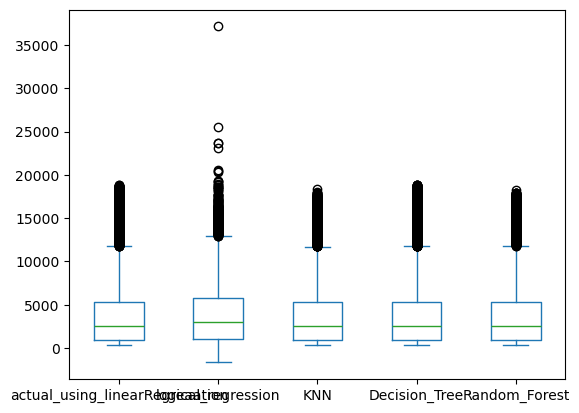

In [424]:
data.plot(kind="box")